# 05f - SegFormer-B2

**Paper**: Xie et al., *SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers*, NeurIPS 2021. arXiv:2105.15203

**Arquitectura**: MiT-B2 encoder (HuggingFace `nvidia/mit-b2`) + decoder MLP ligero. La salida del decoder es H/4×W/4 y se upsamplea bilinearmente a 256×256.

**Hiperparámetros**:
| Parámetro | Valor |
|-----------|-------|
| Backbone | MiT-B2 (pretrained, HuggingFace) |
| Parámetros | ~27.35M |
| Loss | CrossEntropyLoss (ignore_index=255) |
| Optimizer | AdamW (lr=6e-5, wd=0.01, betas=(0.9, 0.999)) |
| Scheduler | CosineAnnealingLR (T_max=30, eta_min=1e-6) |
| Batch size | 16 |
| Max epochs | 80 |
| Early stopping | patience=7 sobre val mIoU |
| Seeds | [42, 123, 7] |

**Referencia histórica** (subset 2.100 imgs — DEPRECADO):
```
mIoU = 0.7592 ± 0.0078   seed: 0.7547 | 0.7701 | 0.7526
```

## 0. Imports y configuración

In [ ]:
import sys
from pathlib import Path

# ── Compatibilidad local / Google Colab ──────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    NOTEBOOKS_DIR = Path('/content/drive/MyDrive/ai4mars_DL-v3/notebooks')
    sys.path.append(str(NOTEBOOKS_DIR))
    print("Entorno: Google Colab")
except ImportError:
    print("Entorno: local")

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation

from mars_utils import (
    # Rutas y constantes
    NUM_CLASSES, IGNORE_INDEX, BATCH_SIZE, SEEDS,
    PROCESSED_DIR, BENCHMARK_CSV
    # Datos
    load_split, load_norm_stats,
    # Entrenamiento
    run_multi_seed,
    # Resultados
    append_benchmark_results, print_summary_table, plot_best_seed_curves,
    # Visualización
    visualize_predictions,
    # Utilidades
    count_parameters, set_seed,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Entorno: local
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.4 GB


## 1. Carga de datos

In [2]:
df_train, df_val, df_gold = load_split()
mean, std = load_norm_stats()

print(f"Train: {len(df_train)} imágenes")
print(f"Val:   {len(df_val)} imágenes")
print(f"Gold:  {len(df_gold)} imágenes")
print(f"Normalización — mean: {mean} | std: {std}")

✅ Split cargado — train: 4200 | val: 1800 | gold test: 322
Train: 4200 imágenes
Val:   1800 imágenes
Gold:  322 imágenes
Normalización — mean: [0.2303263779898021, 0.2303263779898021, 0.2303263779898021] | std: [0.10591342097577364, 0.10591342097577364, 0.10591342097577364]


## 2. Definición del modelo

Se carga `nvidia/mit-b2` desde HuggingFace con pesos preentrenados en ImageNet-1k.
El decoder MLP interno de SegFormer se adapta a `NUM_CLASSES=4`.

In [3]:
MODEL_ID = "nvidia/mit-b2"

def build_segformer():
    """
    Devuelve una instancia de SegFormer-B2 preentrenada adaptada a 4 clases.
    La salida del forward es un tensor [B, 4, H/4, W/4] que se upsamplea
    bilinearmente a [B, 4, 256, 256] en el wrapper.
    """
    model = SegformerForSemanticSegmentation.from_pretrained(
        MODEL_ID,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True,   # reemplaza la cabeza clasificadora
    )
    return SegFormerWrapper(model)


class SegFormerWrapper(nn.Module):
    """
    Wrapper que adapta la salida de HuggingFace SegFormer al formato
    esperado por mars_utils: tensor [B, C, H, W] a resolución completa.

    HuggingFace devuelve logits en H/4×W/4. Los upsampleamos bilinearmente
    a IMG_SIZE×IMG_SIZE (256×256) para que MetricsAccumulator y las losses
    trabajen a la misma resolución que las máscaras.
    """
    def __init__(self, hf_model, img_size: int = 256):
        super().__init__()
        self.model    = hf_model
        self.img_size = img_size

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        out    = self.model(pixel_values=pixel_values)
        logits = out.logits                          # [B, 4, H/4, W/4]
        logits = F.interpolate(
            logits,
            size=(self.img_size, self.img_size),
            mode='bilinear',
            align_corners=False,
        )                                            # [B, 4, 256, 256]
        return logits


# Verificación rápida de la arquitectura
set_seed(42)
_model = build_segformer()
print(f"Parámetros totales: {count_parameters(_model):.2f}M")

_dummy = torch.randn(2, 3, 256, 256)
_out   = _model(_dummy)
print(f"Input shape:  {_dummy.shape}")
print(f"Output shape: {_out.shape}   (esperado: [2, 4, 256, 256])")
del _model, _dummy, _out

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.linear_fuse.weight                          

Parámetros totales: 27.35M
Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 4, 256, 256])   (esperado: [2, 4, 256, 256])


In [4]:
from mars_utils import DATA_DIR
print(list((DATA_DIR / "images_256").iterdir())[:3])
print(list((DATA_DIR / "masks_256").iterdir())[:3])

[WindowsPath('C:/Users/User/Documents/DeepLearning/ai4mars_DL-v3/data/images_256/NLA_397681586EDR_F0020000AUT_04096M1.jpg'), WindowsPath('C:/Users/User/Documents/DeepLearning/ai4mars_DL-v3/data/images_256/NLA_397681801EDR_F0020000AUT_04096M1.jpg'), WindowsPath('C:/Users/User/Documents/DeepLearning/ai4mars_DL-v3/data/images_256/NLA_397681867EDR_F0020000AUT_04096M1.jpg')]
[WindowsPath('C:/Users/User/Documents/DeepLearning/ai4mars_DL-v3/data/masks_256/NLA_397681586EDR_F0020000AUT_04096M1.png'), WindowsPath('C:/Users/User/Documents/DeepLearning/ai4mars_DL-v3/data/masks_256/NLA_397681801EDR_F0020000AUT_04096M1.png'), WindowsPath('C:/Users/User/Documents/DeepLearning/ai4mars_DL-v3/data/masks_256/NLA_397681867EDR_F0020000AUT_04096M1.png')]


## 3. Configuración de hiperparámetros

In [5]:
# ── Loss ─────────────────────────────────────────────────────────────────────
def criterion_fn():
    return nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

# ── Optimizer ────────────────────────────────────────────────────────────────
def optimizer_fn(params):
    return torch.optim.AdamW(
        params,
        lr=6e-5,
        weight_decay=0.01,
        betas=(0.9, 0.999),
    )

# ── Scheduler ────────────────────────────────────────────────────────────────
def scheduler_fn(optimizer):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=30,
        eta_min=1e-6,
    )

print("Hiperparámetros configurados:")
print("  Loss:      CrossEntropyLoss (ignore_index=255)")
print("  Optimizer: AdamW (lr=6e-5, wd=0.01, betas=(0.9, 0.999))")
print("  Scheduler: CosineAnnealingLR (T_max=30, eta_min=1e-6)")

Hiperparámetros configurados:
  Loss:      CrossEntropyLoss (ignore_index=255)
  Optimizer: AdamW (lr=6e-5, wd=0.01, betas=(0.9, 0.999))
  Scheduler: CosineAnnealingLR (T_max=30, eta_min=1e-6)


## 4. Entrenamiento multi-seed

**Modo rápido** (`fast_subset=True`): usa ~200 imágenes de train y ~50 de val.
Sirve para verificar que el pipeline no tiene errores antes de correr el entrenamiento completo.
Cambiar a `fast_subset=False` para el entrenamiento real.

> ⚠️ Tiempo estimado en RTX 4050 (6GB): ~11h con `fast_subset=False`.

In [6]:
# ── Cambiar fast_subset=False para entrenamiento real ────────────────────────
FAST_SUBSET = False   # True = prueba rápida | False = entrenamiento completo

summary = run_multi_seed(
    model_fn      = build_segformer,
    df_train      = df_train,
    df_val        = df_val,
    df_gold       = df_gold,
    criterion_fn  = criterion_fn,
    optimizer_fn  = optimizer_fn,
    scheduler_fn  = scheduler_fn,
    model_name    = "SegFormer-B2",
    device        = DEVICE,
    seeds         = SEEDS,
    num_epochs    = 80,
    patience      = 10,
    batch_size    = BATCH_SIZE,
    num_workers   = 4,
    use_amp       = True,
    fast_subset   = FAST_SUBSET,
    n_train_fast  = 200,
    n_val_fast    = 50,
)

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.



───────────────────────────────────────────────────────
  Seed 42 | SegFormer-B2


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.linear_fuse.weight                          

  Entrenamiento desde cero

  SegFormer-B2_seed42 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep   1/80 | loss=0.2566 mIoU=0.6281 | val_loss=0.1958 val_mIoU=0.7070 | rock=0.2700
Ep   2/80 | loss=0.1605 mIoU=0.7253 | val_loss=0.1276 val_mIoU=0.7661 | rock=0.3482
Ep   3/80 | loss=0.1378 mIoU=0.7575 | val_loss=0.1044 val_mIoU=0.7864 | rock=0.3749
Checkpoint periódico guardado (epoch 3)
Ep   4/80 | loss=0.1206 mIoU=0.7778 | val_loss=0.1038 val_mIoU=0.8060 | rock=0.4540
Ep   5/80 | loss=0.1059 mIoU=0.8074 | val_loss=0.1080 val_mIoU=0.8023 | rock=0.4632
Ep   6/80 | loss=0.0988 mIoU=0.8151 | val_loss=0.1230 val_mIoU=0.7980 | rock=0.4512
Checkpoint periódico guardado (epoch 6)
Ep   7/80 | loss=0.0894 mIoU=0.8334 | val_loss=0.1408 val_mIoU=0.8083 | rock=0.4971
Ep   8/80 | loss=0.0863 mIoU=0.8484 | val_loss=0.1014 val_mIoU=0.8192 | rock=0.5089
Ep   9/80 | loss=0.0781 mIoU=0.8539 | val_loss=0.1108 val_mIoU=0.8085 | rock=0.4861
Checkpoint periódico guardado (epoch 9)
Ep  10

...

  Entrenamiento desde cero

  SegFormer-B2_seed123 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep   1/80 | loss=0.2602 mIoU=0.6317 | val_loss=0.1278 val_mIoU=0.7375 | rock=0.2282
Ep   2/80 | loss=0.1570 mIoU=0.7329 | val_loss=0.1265 val_mIoU=0.7279 | rock=0.1984
Ep   3/80 | loss=0.1326 mIoU=0.7640 | val_loss=0.1186 val_mIoU=0.7832 | rock=0.4009
Checkpoint periódico guardado (epoch 3)
Ep   4/80 | loss=0.1202 mIoU=0.7827 | val_loss=0.1147 val_mIoU=0.7847 | rock=0.4076
Ep   5/80 | loss=0.1182 mIoU=0.7929 | val_loss=0.0998 val_mIoU=0.7984 | rock=0.4239
Ep   6/80 | loss=0.1009 mIoU=0.8136 | val_loss=0.1158 val_mIoU=0.7994 | rock=0.4546
Checkpoint periódico guardado (epoch 6)
Ep   7/80 | loss=0.1002 mIoU=0.8267 | val_loss=0.0998 val_mIoU=0.8012 | rock=0.4315
Ep   8/80 | loss=0.0836 mIoU=0.8441 | val_loss=0.1090 val_mIoU=0.8186 | rock=0.4897
Ep   9/80 | loss=0.0783 mIoU=0.8566 | val_loss=0.1060 val_mIoU=0.8272 | rock=0.5325
Checkpoint periódico guardado (epoch 9)
Ep  1

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.linear_fuse.weight                          

  Entrenamiento desde cero

  SegFormer-B2_seed7 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep   1/80 | loss=0.2566 mIoU=0.6365 | val_loss=0.2052 val_mIoU=0.7221 | rock=0.3151
Ep   2/80 | loss=0.1534 mIoU=0.7306 | val_loss=0.1066 val_mIoU=0.7816 | rock=0.3678
Ep   3/80 | loss=0.1425 mIoU=0.7559 | val_loss=0.1194 val_mIoU=0.7411 | rock=0.2198
Checkpoint periódico guardado (epoch 3)
Ep   4/80 | loss=0.1231 mIoU=0.7790 | val_loss=0.1316 val_mIoU=0.7965 | rock=0.4518
Ep   5/80 | loss=0.1068 mIoU=0.8045 | val_loss=0.1056 val_mIoU=0.7967 | rock=0.4359
Ep   6/80 | loss=0.0942 mIoU=0.8283 | val_loss=0.1289 val_mIoU=0.8080 | rock=0.5010
Checkpoint periódico guardado (epoch 6)
Ep   7/80 | loss=0.0963 mIoU=0.8284 | val_loss=0.1050 val_mIoU=0.8150 | rock=0.4904
Ep   8/80 | loss=0.0838 mIoU=0.8468 | val_loss=0.1091 val_mIoU=0.8107 | rock=0.4914
Ep   9/80 | loss=0.0811 mIoU=0.8568 | val_loss=0.1029 val_mIoU=0.8283 | rock=0.5290
Checkpoint periódico guardado (epoch 9)
Ep  10/

## 5. Resultados

In [7]:
# Tabla resumen agregada (media ± std, IC95%)
print_summary_table(summary)


  RESUMEN — SegFormer-B2
  Métrica                 Media       Std      IC95
  ------------------------------------------------
  mIoU                   0.8337    0.0063  ± 0.0071
  Pixel Accuracy         0.9814
  ------------------------------------------------
  IoU soil               0.9783    0.0021
  IoU bedrock            0.9397    0.0025
  IoU sand               0.9575    0.0057
  IoU big_rock           0.4592    0.0184
  ------------------------------------------------
  Params (M)           —
  Tiempo medio (s)         4241
  Epoch mejor (mean)       25.0



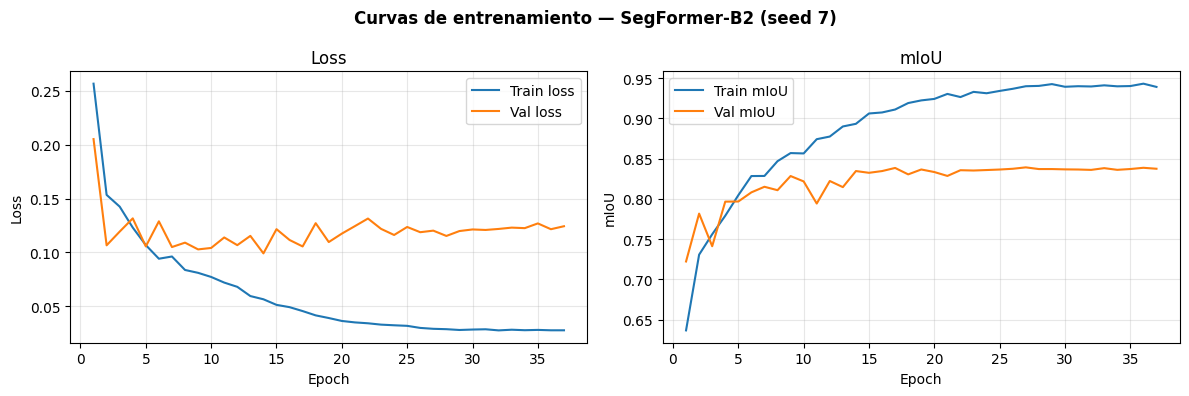

In [8]:
# Curvas de entrenamiento del mejor seed
plot_best_seed_curves(summary)

In [ ]:
# Guardar en benchmark_results.csv
params_M = count_parameters(build_segformer())
df_csv = pd.read_csv(BENCHMARK_CSV)
df_csv = df_csv[df_csv["model"] != MODEL_NAME]
df_csv.to_csv(BENCHMARK_CSV, index=False)
append_benchmark_results(summary, params_M=params_M)
print(f"Parámetros del modelo: {params_M:.2f}M")

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.linear_fuse.weight                          

Resultados guardados en C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\results\benchmark_results.csv
Parámetros del modelo: 27.35M


## 6. Análisis cualitativo

Visualizando predicciones del mejor seed: 7


[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.linear_fuse.weight                          

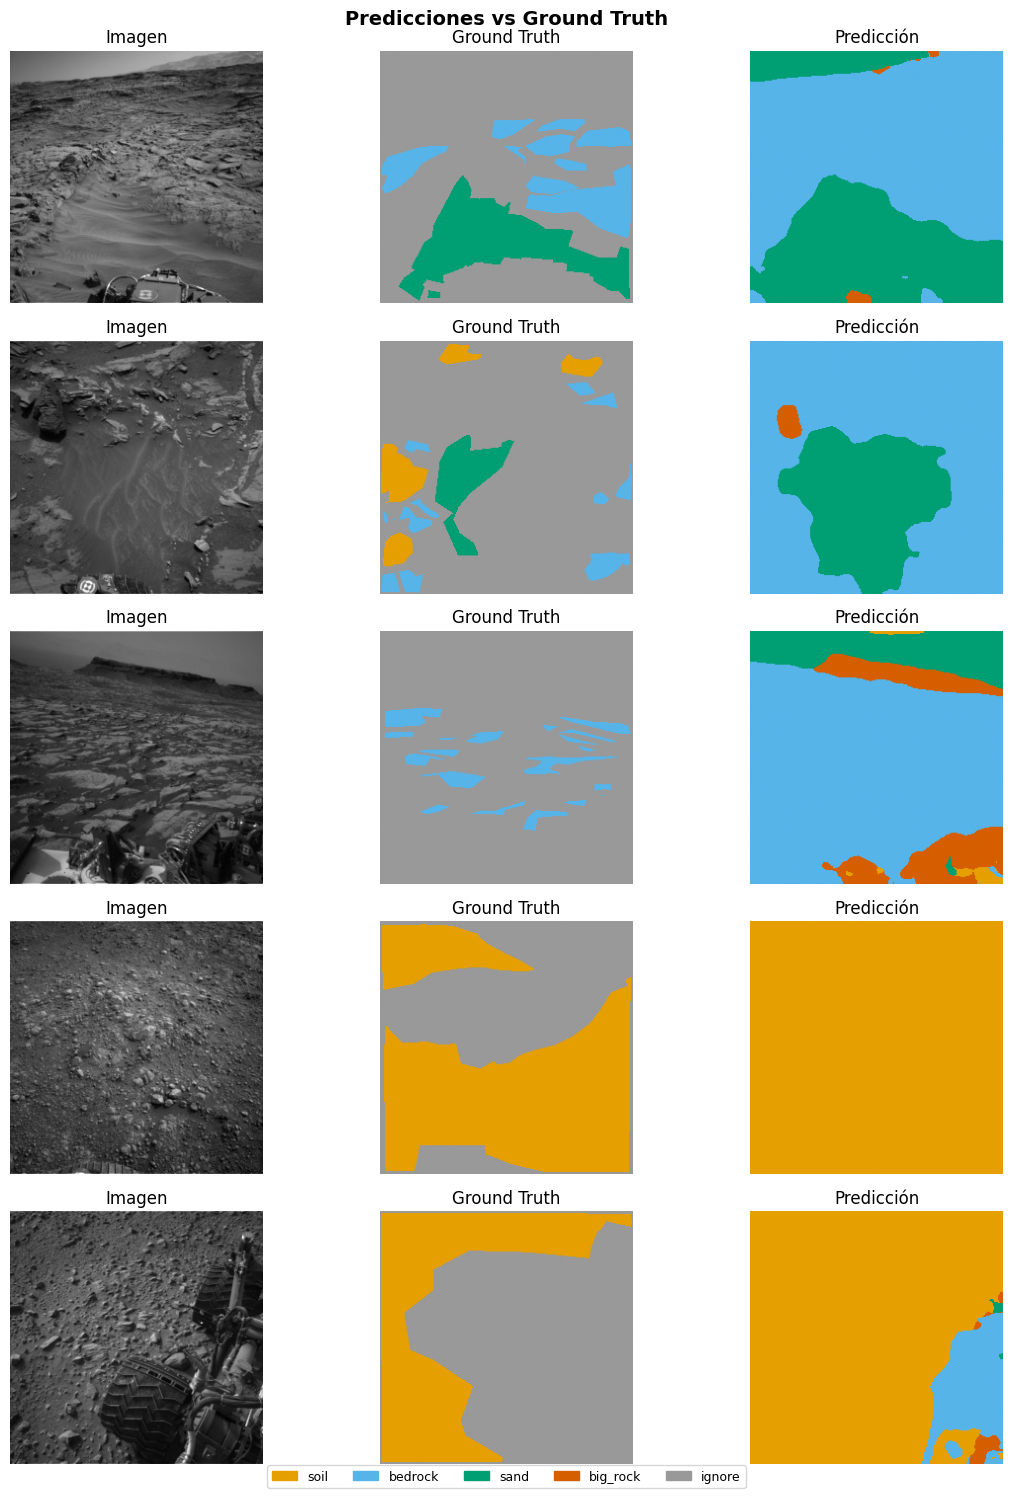

In [10]:
# Visualizar predicciones del mejor seed sobre el gold test set
best_seed = max(summary["per_seed"], key=lambda r: r["mIoU"])["seed"]
print(f"Visualizando predicciones del mejor seed: {best_seed}")

set_seed(best_seed)
best_model = build_segformer().to(DEVICE)

from mars_utils import CHECKPOINTS_DIR
ckpt = torch.load(
    CHECKPOINTS_DIR / f"SegFormer-B2_seed{best_seed}_best.pth",
    map_location=DEVICE,
)
best_model.load_state_dict(ckpt["model_state"])

visualize_predictions(best_model, df_gold, DEVICE, mean=mean, std=std, n=5)